<a href="https://colab.research.google.com/github/Saadmoquim/physicscode/blob/main/SAAD_MOQUIM_IMS22221_assign4.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

## Fourth Assignment

## Problem 1
1. Produce the kde plot for GRB T90 distribution (refer to the Fermi GBM GRB catalog that was shared earlier) using top hat and gaussian kernels for three different bandwidths which include demonstrating the scenario of under-smoothed, over-smoothed and properly smoothed.  

Saving 1_FERMI_GBM_only_catalog_clean.csv to 1_FERMI_GBM_only_catalog_clean.csv


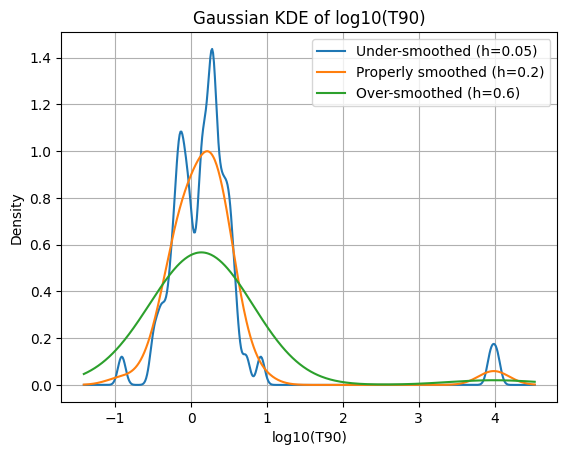

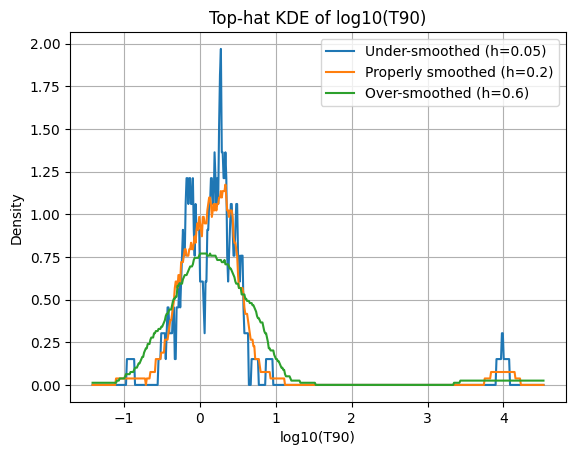

In [1]:
#Enter your solution here

from google.colab import files
uploaded = files.upload()

file_path = list(uploaded.keys())[0]


import pandas as pd
import numpy as np
import matplotlib.pyplot as plt

df = pd.read_csv(file_path, header=None)


t90 = df[2].dropna()
t90 = t90[t90 > 0]

log_t90 = np.log10(t90.values)



def gaussian_kernel(u):
    return (1 / np.sqrt(2 * np.pi)) * np.exp(-0.5 * u**2)

def tophat_kernel(u):
    return 0.5 * (np.abs(u) <= 1)


def kde(x, data, h, kernel):
    n = len(data)
    return np.sum(kernel((x[:, None] - data[None, :]) / h), axis=1) / (n * h)


x_grid = np.linspace(log_t90.min() - 0.5,
                     log_t90.max() + 0.5,
                     500)


bandwidths = [0.05, 0.2, 0.6]
labels = ["Under-smoothed", "Properly smoothed", "Over-smoothed"]


plt.figure()

for h, label in zip(bandwidths, labels):
    y = kde(x_grid, log_t90, h, gaussian_kernel)
    plt.plot(x_grid, y, label=f"{label} (h={h})")

plt.title("Gaussian KDE of log10(T90)")
plt.xlabel("log10(T90)")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()


plt.figure()

for h, label in zip(bandwidths, labels):
    y = kde(x_grid, log_t90, h, tophat_kernel)
    plt.plot(x_grid, y, label=f"{label} (h={h})")

plt.title("Top-hat KDE of log10(T90)")
plt.xlabel("log10(T90)")
plt.ylabel("Density")
plt.legend()
plt.grid()
plt.show()

# Problem 2
2. Use the Savgol filter to produce the smoothed curve of the sample dataset below that consists of the minimum temperatures across the months of the year from the Southern Hemisphere from 1981 to 1990 (data filename: daily-min-temperatures.csv).

Saving daily-min-temperatures.csv to daily-min-temperatures.csv


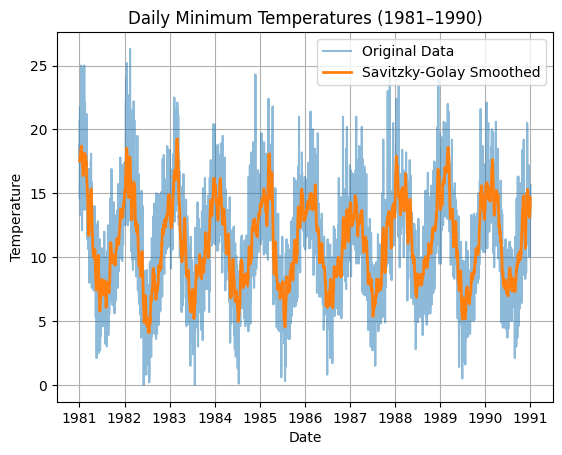

In [2]:
# Enter your solution here

from google.colab import files
uploaded = files.upload()

file_path = list(uploaded.keys())[0]

import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter

df = pd.read_csv(file_path)

df['Date'] = pd.to_datetime(df['Date'])

temp = df['Temp'].values

window_length = 31
polyorder = 3

smoothed = savgol_filter(temp, window_length=window_length, polyorder=polyorder)

plt.figure()

plt.plot(df['Date'], temp, alpha=0.5, label="Original Data")
plt.plot(df['Date'], smoothed, linewidth=2, label="Savitzky-Golay Smoothed")

plt.title("Daily Minimum Temperatures (1981–1990)")
plt.xlabel("Date")
plt.ylabel("Temperature")
plt.legend()
plt.grid()

plt.show()

## Problem 3
3. Using the fits data file for the GRB160624477,
(a) Plot the lightcurve of the GRB using an appropriate bin width such that the GRB is visible (has a good signal to noise ratio).
Note: Lightcurve is just the histogram of the TIME column data (available within the fits file).
The Trigger time of the GRB is 488460437.76 s. Please choose the data between -50 s to +50s around the trigger time of the GRB.  

(b) Compare the signal to noise ratio of the GRB detection in three different binwidths: 0.01s, 1s and 10 s.

Saving glg_tte_n2_bn160624477_v00.tte to glg_tte_n2_bn160624477_v00.tte


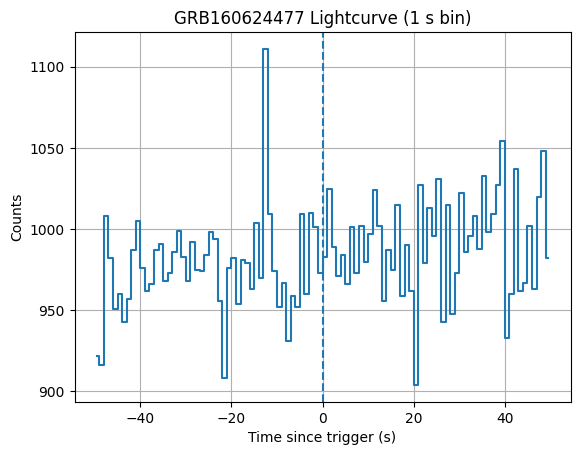

Bin width =  0.01 s  →  SNR = 4.520
Bin width =   1.0 s  →  SNR = 4.088
Bin width =  10.0 s  →  SNR = 2.950


In [3]:
# Enter your solution here

from google.colab import files
uploaded = files.upload()

file_path = list(uploaded.keys())[0]

import numpy as np
import matplotlib.pyplot as plt
from astropy.io import fits

hdul = fits.open(file_path)

events = hdul[2].data
time = events['TIME']

trigger = 488460437.76

mask = (time >= trigger - 50) & (time <= trigger + 50)
t = time[mask] - trigger

def compute_lightcurve_and_snr(t, bin_width):

    bins = np.arange(-50, 50 + bin_width, bin_width)
    counts, edges = np.histogram(t, bins=bins)

    bin_centers = 0.5 * (edges[:-1] + edges[1:])


    bg_mask = (bin_centers < -20) | (bin_centers > 20)
    background = np.mean(counts[bg_mask])


    signal = np.max(counts) - background


    noise = np.sqrt(background) if background > 0 else 1

    snr = signal / noise

    return bin_centers, counts, snr

bin_width = 1.0

bin_centers, counts, snr = compute_lightcurve_and_snr(t, bin_width)

plt.figure()
plt.step(bin_centers, counts, where='mid')
plt.axvline(0, linestyle='--')
plt.title("GRB160624477 Lightcurve (1 s bin)")
plt.xlabel("Time since trigger (s)")
plt.ylabel("Counts")
plt.grid()
plt.show()

bin_widths = [0.01, 1.0, 10.0]

for bw in bin_widths:
    _, _, snr_val = compute_lightcurve_and_snr(t, bw)
    print(f"Bin width = {bw:>5} s  →  SNR = {snr_val:.3f}")

Because of the trade-off between statistical fluctuations and temporal resolution, the signal-to-noise ratio is highly dependent on bin width. While very high bin widths (10 s) dilute the burst signal by averaging it with background, very narrow bin widths (0.01 s) suffer from low counts per bin, increasing Poisson noise. An ideal equilibrium is provided by an intermediate bin width (~1 s), which maximizes the GRB's detectability.